
<div align="center">
    <img src="logo.png" alt="Logo" width="25%">
</div>

# **Challenge : Molecular Property Prediction**

___
*Matthieu Kaeppelin (M2DS)*

*Bastien Lecomte (M2DS)*

*Antoine Verier (M2DS)*

*Thomas Vujasinovic (M2DS)*

*Kam Osiris Yetna (M2DS)*
___

# Introduction


- The data for this challenge comes from a subset of the MoleculeNet dataset, a globally recognized benchmark for evaluating machine learning algorithms in chemistry.

- More specifically, this challenge is based on the `molvision/BACE-V-SMILES-0` dataset. It contains SMILES representations (*Simplified Molecular-Input Line-Entry System*) of a large set of chemical compounds, which have been experimentally tested in vitro to assess their ability to inhibit the Beta-secretase 1 enzyme (BACE-1).

### **What is the objective of the task ?** 

Your mission is to design a robust binary classification model. Your algorithm will take the SMILES string of a molecule as input and predict its efficacy as a BACE-1 inhibitor by assigning it a label:

- Label = 1: The molecule is an active inhibitor of BACE-1.

- Label = 0: The molecule is inactive.

### **Why does it matters ?**

The enzyme BACE-1 plays a central role in the formation of amyloid plaques in the brain, one of the main pathological characteristics of Alzheimer's disease. It is therefore a major therapeutic target.
However, developing a new drug is an extremely cumbersome process. Physically testing millions of chemical compounds in the laboratory is an impossible approach on a large scale.

This is where machine learning becomes crucial. Being able to predict the activity of these inhibitors computationally (in silico) makes it possible to quickly filter candidate molecules, drastically reduce clinical failures, and accelerate the discovery of new treatments.


### **Out-of-distribution test set**

This is not a standard random-split challenge. The dataset has been strictly split based on Molecular Weight (MW):

- Train set: it contains smaller molecules (MW < 592 Da).

- Hidden test set: it contains exclusively larger molecules (MW ≥ 592 Da).

Your model must prove it has learned true chemical rules to extrapolate to uncharted chemical space, rather than just memorizing the training statistics! 

***NB** : You are not allowed to use the molecules of the hidden test set for training or validation. Any attempt to do so will lead to disqualification.*

### **First steps to help you get started:**

To manipulate the chemical data in the challenge, we strongly recommend using RDKit, the leading Python library for chemoinformatics. Its `Chem` module will allow you to easily convert SMILES text strings into more manageable molecular objects, then generate numerical descriptors (such as Morgan Fingerprints) that can be directly used by your machine learning models. RDKit is a powerful tool that will greatly facilitate your task of extracting the relevant characteristics of your molecules and climbing to the top of the rankings! 

RDKit documentation: https://www.rdkit.org/docs/GettingStartedInPython.html


___

# Exploratory data analysis

- Here we perform a preliminary analysis to show you how to load the data, visualize it, and extract some basic insights. This will help you understand the structure of the dataset and guide your feature engineering and modeling efforts.

In [1]:
# install dependencies
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, rdFingerprintGenerator
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score

pd.set_option('display.max_columns', None)

### **Downloading public Data**

In [3]:
# uncomment the following line to download the data
# %run tools/setup_data.py 

### **Loading data**

In [4]:
input_dir = 'dev_phase/input_data'
reference_dir = 'dev_phase/reference_data'

Function to load the data :

In [5]:
def get_data():
    """Load X_train, y_train and X_test from csv files."""
    train = pd.read_csv(os.path.join(input_dir, 'train/train_features.csv'))
    X_train = train['SMILES']

    train_labels = pd.read_csv(os.path.join(input_dir, 'train/train_labels.csv'))
    y_train = train_labels['Label']
    
    test = pd.read_csv(os.path.join(input_dir, 'test/test_features.csv'))
    X_test = test['SMILES']

    return X_train, y_train, X_test

X_train, y_train, X_test =  get_data() 

**First exploration of the data**

In [6]:
print(f"Number of molecules in train set: {len(X_train)}")
X_train.head()

Number of molecules in train set: 683


0            Oc1ccc(cc1)CC[NH3+]
1              n1ccc2c(cccc2)c1N
2         Oc1ccc(cc1)CC([NH3+])C
3           O=C1NC(=NC(=C1)CCC)N
4    Oc1ccc(cc1C1CCCCC1)CC[NH3+]
Name: SMILES, dtype: str

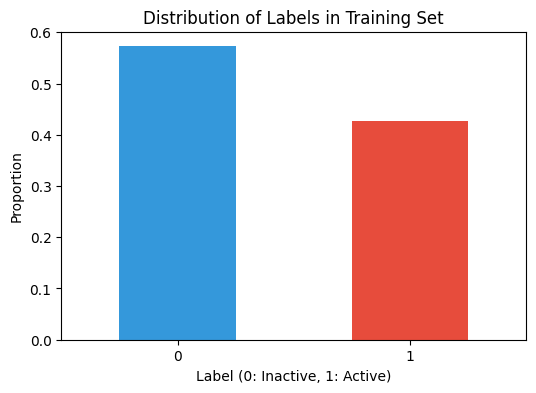

Label
0    391
1    292
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(6, 4))
y_train.value_counts(normalize=True).plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribution of Labels in Training Set')
plt.xlabel('Label (0: Inactive, 1: Active)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

print(y_train.value_counts())

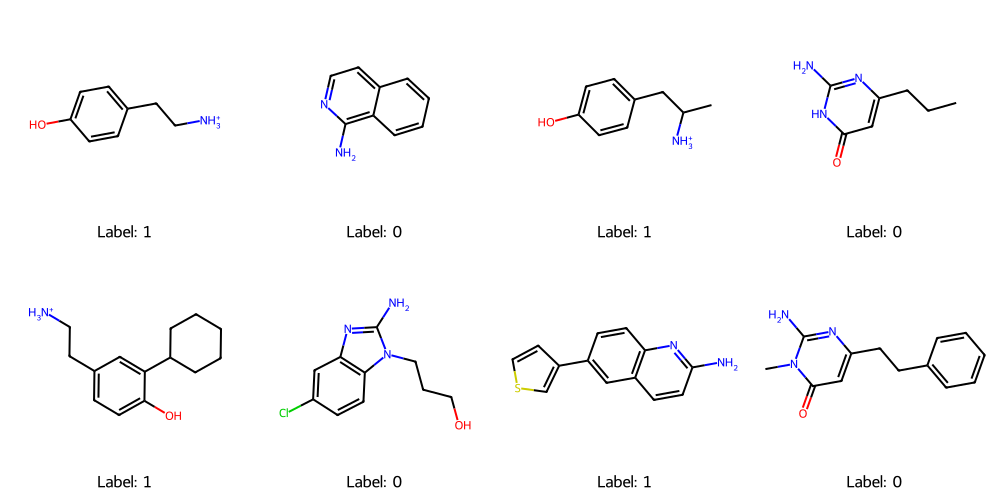

In [8]:
mols = [Chem.MolFromSmiles(smiles) for smiles in X_train.head(8)]
labels = [f"Label: {l}" for l in y_train.head(8).values]

# Plot them in a grid
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250), legends=labels)
img

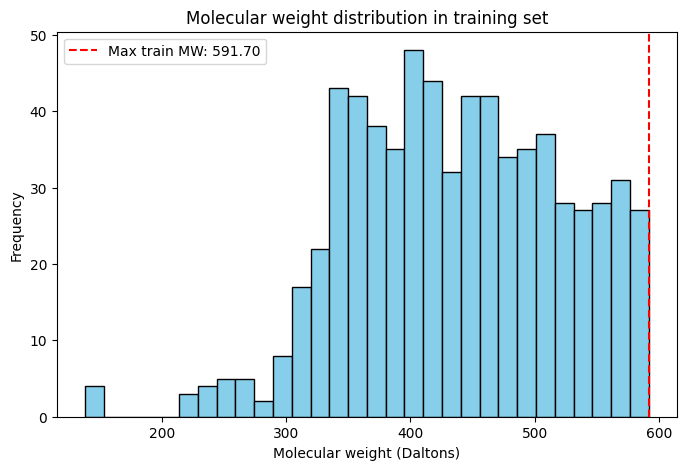

In [9]:
# Calculate Molecular Weight for all training molecules
MW = X_train.apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))

plt.figure(figsize=(8, 5))
plt.hist(MW, bins=30, color='skyblue', edgecolor='black')
plt.title('Molecular weight distribution in training set')
plt.xlabel('Molecular weight (Daltons)')
plt.ylabel('Frequency')
plt.axvline(x=MW.max(), color='red', linestyle='--', label=f'Max train MW: {MW.max():.2f}')
plt.legend()
plt.show()

The training set abruptly stops before 600 Daltons. Prepare your model to face much heavier molecules in the private test set !

# Challenge evaluation and metric :

Because of the class imbalance and the out-of-distribution nature of the test set (keep in mind that you are not allowed to use the molecules of the hidden test set for training or validation !), the evaluation of your model's performance cannot rely on a simple accuracy score.

That's why the metric used for this challenge is the Cohen's Kappa Score. It is defined as
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$
where $p_o$ is the empirical probability of agreement on the label assigned to any sample (the observed agreement ratio), and $p_e$ is the expected agreement when both annotators assign labels randomly. $p_e$ is estimated using a per-annotator empirical prior over the class labels. We use the `sklearn.metrics.cohen_kappa_score` function to compute this metric.

Unlike the classical accuracy, the Kappa score evaluates the actual agreement between your predictions and the true labels, while mathematically subtracting the probability that such an agreement would occur by chance. This ensures that your ranking position reflects the true capability of your model to identify inhibitors.

# Baseline

Here, you should describe the submission format. This is the format the participants should follow to submit their predictions on the codabench platform.

In [10]:
class RFMorganBaseline(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, radius=2, nBits=1024):
        """
        Baseline model converting SMILES to Morgan Fingerprints
        and training a Random Forest.
        """
        self.n_estimators = n_estimators
        self.radius = radius
        self.nBits = nBits
        self.model = RandomForestClassifier(
            n_estimators=self.n_estimators, 
            random_state=42,
            n_jobs=-1
        )
        # Initialize the Morgan fingerprint generator
        self.mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=self.radius, fpSize=self.nBits)
        
    def _smiles_to_fps(self, X):
        fps = []
        for smiles in X:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                # Calculate Morgan Fingerprint (equivalent to ECFP4 if radius=2)
                fp = self.mfpgen.GetFingerprintAsNumPy(mol)
                fps.append(fp)
            else:
                # Handle invalid smiles
                fps.append(np.zeros(self.nBits))
        return np.array(fps)

    def fit(self, X, y):
        """
        Training of the model
        """
        print("Converting SMILES to Morgan Fingerprints...")
        X_fp = self._smiles_to_fps(X)
        
        print(f"Training Random Forest with {self.n_estimators} estimators...")
        self.model.fit(X_fp, y)
        self.classes_ = self.model.classes_
        return self

    def predict_proba(self, X):
        """
        Probability prediction
        """
        X_fp = self._smiles_to_fps(X)
        return self.model.predict_proba(X_fp)

    def predict(self, X):
        """
        Class prediction
        """
        X_fp = self._smiles_to_fps(X)
        return self.model.predict(X_fp)

def get_model():
    """
    Returns the baseline model.
    """
    return RFMorganBaseline(n_estimators=100, radius=2, nBits=1024)

# **The submission file**

Your submission file should be `.py` file containging a scikit-learn compatible estimator class with  `fit`, `predict` and `predict_proba` methods. You can find an example implementation in the `solution/submission.py` file.

# Local testing pipeline

Here you see how to test your model locally before submitting it on the platform. You can use the `evaluate_submission` function to compute the Kappa score of your predictions on the local test set. This will allow you to quickly iterate and improve your model before making a submission on Codabench.

In [11]:
model = get_model()
model.fit(X_train, y_train)

Converting SMILES to Morgan Fingerprints...
Training Random Forest with 100 estimators...


,n_estimators,100
,radius,2
,nBits,1024


### Testing the model

In [12]:
y_pred = model.predict(X_test)
y_test = pd.read_csv(os.path.join(reference_dir, 'test_labels.csv'))
def compute_kappa(predictions, targets):
    # Return mean of correct predictions
    return cohen_kappa_score(predictions, targets)

#from scoring_program.scoring import compute_kappa
print("Accuracy on test set:", compute_kappa(y_pred, y_test))

Accuracy on test set: 0.31297242083758936


## Submission

To submit your code, you can refer to the actual challenge.